In [34]:
# Libraries, modules
import soundfile as sf
import matplotlib.pyplot as plt
import os
import soundfile as sf
import numpy as np
from scipy.signal import square, ShortTimeFFT
from scipy.signal.windows import hann
import cv2
from skimage.feature import peak_local_max

rec_filename = "000_1.392_seq.flac"

# Read full audio recording
data, fs = sf.read("./signal_sequences/"+rec_filename)
l_ch = data[:,0] # Left channel
#r_ch = data[:,1] # Right channel

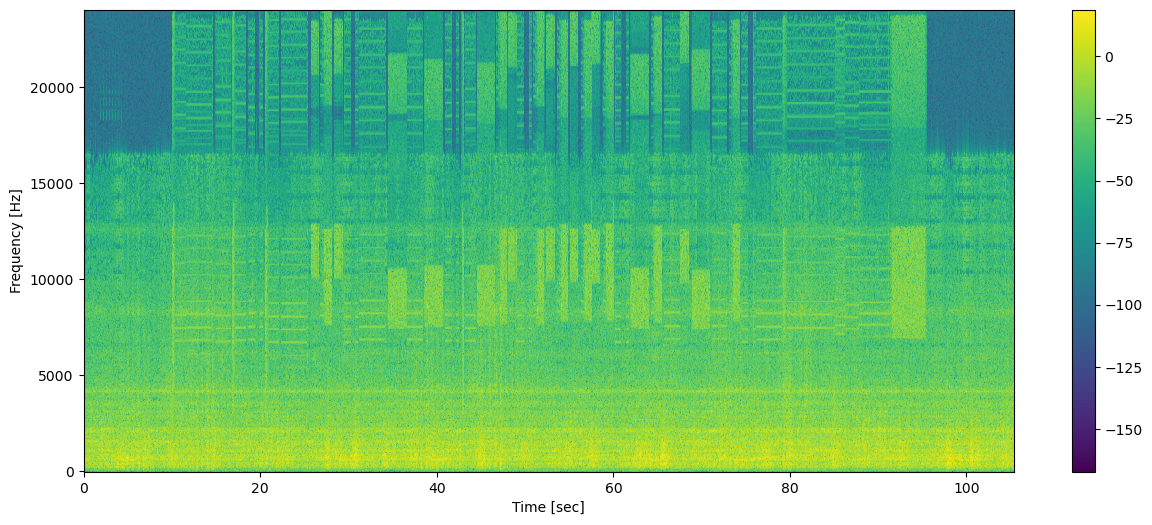

In [35]:
## Generate Spectrogram (2D FFT)

## Parameters
win_size = 1024  # Window size, 1024 to 4096 are ideal
hop_size = int(win_size*0.5)  # Overlap
fs = 48000  # Your sampling frequency
win = hann(win_size)

SFT = ShortTimeFFT(win, hop=hop_size, fs=fs) # Initialize ShortTimeFFT
Sx2 = SFT.spectrogram(l_ch) # Compute the spectrogram (absolute square of STFT)
Sx2[Sx2 == 0] = np.min(Sx2[np.nonzero(Sx2)]) # Substitute zeros with the minimum non-zero value to avoid log(0)
Sx2_dB = 10 * np.log10(Sx2) # Convert spectrogram to dB
t_min, t_max, f_min, f_max = SFT.extent(len(data), center_bins=True) # Get frequency and time boundaries
f_bins, t_bins = Sx2.shape # Get the number of frequency and time bins

# Plot the full spectrogram in dB
plt.figure(figsize=(15, 6))
plt.pcolormesh(np.linspace(t_min, t_max, t_bins), np.linspace(f_min, f_max, f_bins), Sx2_dB)
plt.colorbar()
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.show()

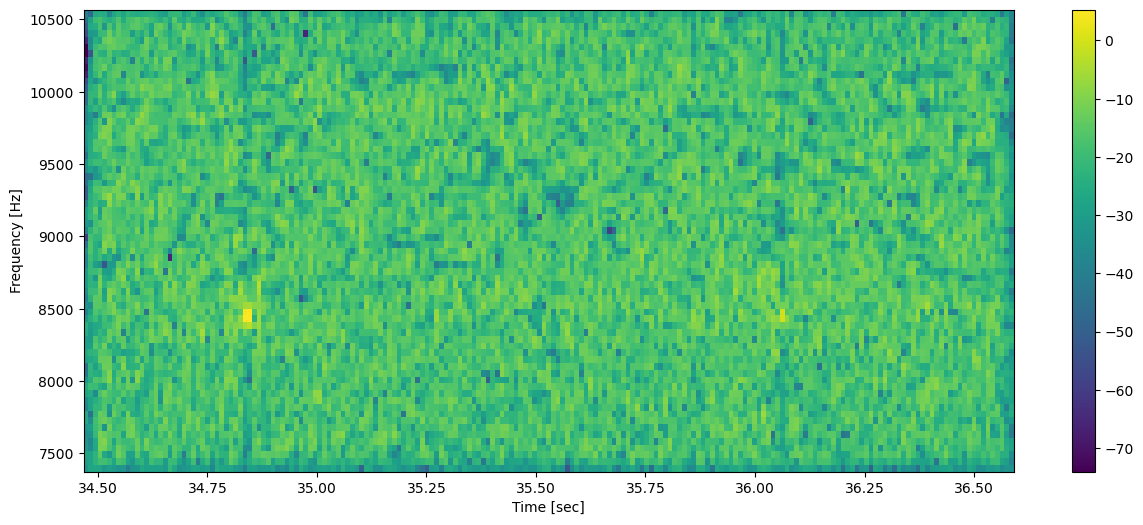

In [36]:
## Crop to signal G
# Frequency range
f_low = 7430  # Hz
f_high = 10600  # Hz
f_0 = int(f_low * f_bins / (f_max - f_min))
f_1 = int(f_high * f_bins / (f_max - f_min))

# Time range
t_start = 34.47
t_end = 36.59
t_0 = np.searchsorted(np.linspace(t_min, t_max, t_bins), t_start)
t_1 = np.searchsorted(np.linspace(t_min, t_max, t_bins), t_end)

# Crop the spectrogram to the selected frequency and time ranges
signal_spec = Sx2_dB[f_0:f_1, t_0:t_1]

# Plot the cropped spectrogram in dB
plt.figure(figsize=(15, 6))
plt.pcolormesh(np.linspace(t_min, t_max, t_bins)[t_0:t_1], np.linspace(f_min, f_max, f_bins)[f_0:f_1], signal_spec)
plt.colorbar()
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.show()

In [37]:
np.savetxt('signal_samples/G_signal_48k-1024.csv', signal_spec, delimiter=',')

(68, 199)

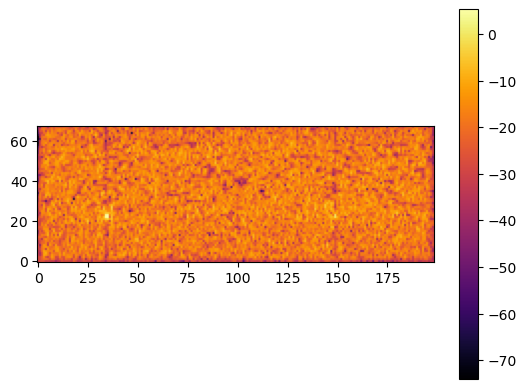

In [39]:
# Load G signal
endsig = np.genfromtxt('signal_samples/G_signal_48k-1024.csv', delimiter=',')

# Define end signal array
end_signal = endsig.astype(np.float32)
plt.imshow(end_signal, origin='lower', cmap="inferno")
plt.colorbar()
end_signal.shape